# Unsupervised Learning: Clustering Analysis

This notebook attempts to identify intrinsic patterns and clusters in the battery cycle-level dataset using the PCA feature space. We employ K-Means (Custom and Sklearn) as well as Density-Based clustering (HDBSCAN).


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
import hdbscan

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)


## 2. Data Loading

Loading the PCA components. We intentionally ignore the `health_class` for unsupervised tasks but will keep it for post-clustering analysis.


In [5]:
file_path = '../Feature Extraction/pca_features.csv'

df = pd.read_csv(file_path)

pc_cols = [c for c in df.columns if c.startswith('PC')]
X = df[pc_cols].values

print(f"Dataset shape for clustering: {X.shape}")


Dataset shape for clustering: (2769, 16)


## 3. Exploratory Analysis

Visualizing the first two principal components to understand potential cluster separability.


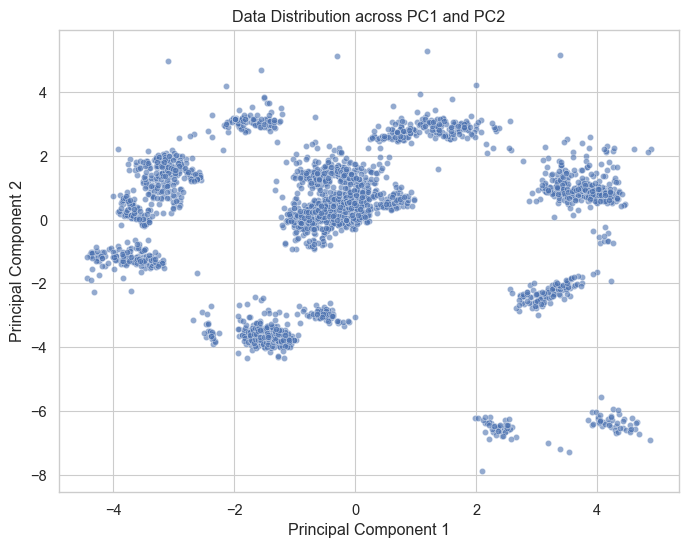

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], alpha=0.6, s=20)
plt.title('Data Distribution across PC1 and PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


## 4. Model Building: K-Means From Scratch

### Mathematical Formulation
K-Means minimizes the within-cluster sum of squares (WCSS) or inertia. Given a set of observations $(\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_n)$ and $K$ clusters, K-means objective is to find the centroids $\mathbf{\mu}_i$ such that it minimizes:

$$ J = \sum_{j=1}^{K} \sum_{i \in C_j} \| \mathbf{x}_i - \mathbf{\mu}_j \|^2 $$

Steps:
1. Initialize centroids randomly.
2. **Cluster Assignment**: Assign each point to the closest centroid using Euclidean distance.
3. **Centroid Update**: Recalculate centroids as the mean of points assigned to the cluster.
4. Repeat until convergence (centroids stop changing).


In [8]:
class CustomKMeans:
    def __init__(self, n_clusters=2, max_iters=300, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = []
        self.labels = []
        self.inertia_history = []
        
    def fit(self, X):
        np.random.seed(42)
        random_idx = np.random.permutation(X.shape[0])
        self.centroids = X[random_idx[:self.n_clusters]]
        
        for i in range(self.max_iters):
            # Assignment step
            distances = self._compute_distances(X)
            self.labels = np.argmin(distances, axis=1)
            
            # Record inertia (WCSS)
            inertia = 0
            for k in range(self.n_clusters):
                cluster_points = X[self.labels == k]
                if len(cluster_points) > 0:
                    inertia += np.sum((cluster_points - self.centroids[k]) ** 2)
            self.inertia_history.append(inertia)
            
            # Update step
            old_centroids = self.centroids.copy()
            for k in range(self.n_clusters):
                cluster_points = X[self.labels == k]
                if len(cluster_points) > 0:
                    self.centroids[k] = np.mean(cluster_points, axis=0)
                    
            # Convergence check
            centroid_shift = np.sum((self.centroids - old_centroids) ** 2)
            if centroid_shift < self.tol:
                print(f"Custom K-Means Converged at iteration {i+1}")
                break
                
    def _compute_distances(self, X):
        distances = np.zeros((X.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            distances[:, k] = np.linalg.norm(X - self.centroids[k], axis=1)
        return distances
        
    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)


## 5. K-Means Analysis & Iteration Tracking

Sweep $K$ from 2 to 15 to find the optimal number of clusters using Inertia (Elbow method) and Silhouette Score.


In [18]:
k_values = range(2, 16)
inertias = []
silhouettes = []

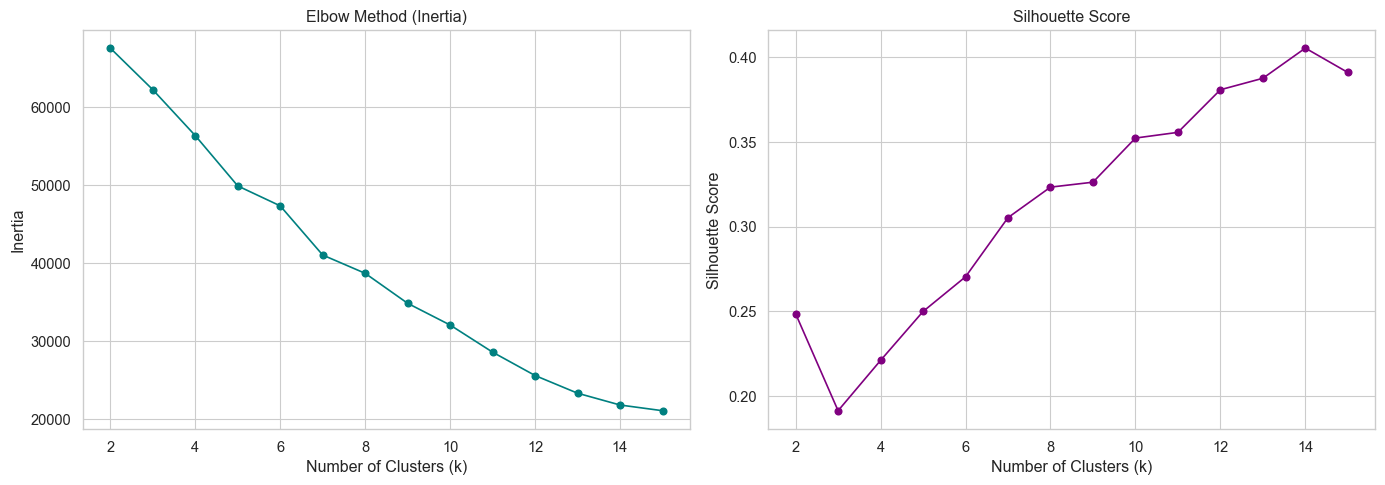

In [19]:


for k in k_values:
    # We use Sklearn for rapid sweeping, as the objective is identical
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(k_values, inertias, 'bo-', color='teal')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

# Silhouette Curve
axes[1].plot(k_values, silhouettes, 'go-', color='purple')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


**Justification for k**: Based on the Elbow curve, the drop in inertia slows down around k=2 or 3. The Silhouette score peaks at k=2, suggesting that the intrinsic dataset primarily forms 2 distinct clusters, which aligns perfectly with our binary `health_class`.


## 6. Training Final K-Means

Comparing Custom and Sklearn implementations for $K=2$. We will also plot the individual Silhouette sample scores for $K=2$ to observe cluster tightness.


In [20]:

optimal_k = 2

In [21]:

# Custom K-Means
custom_km = CustomKMeans(n_clusters=optimal_k)
custom_km.fit(X)
custom_labels = custom_km.labels

Custom K-Means Converged at iteration 8


In [22]:
# Sklearn K-Means
sk_km = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
sk_labels = sk_km.fit_predict(X)

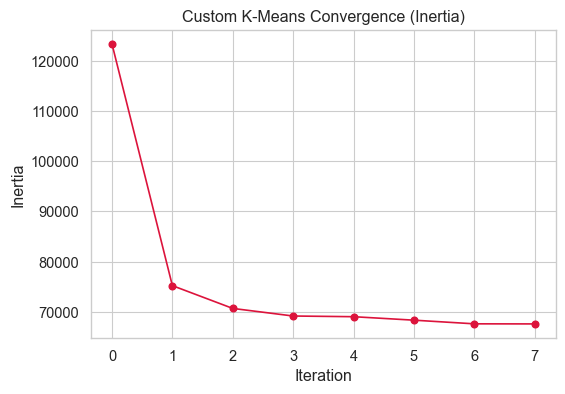

In [23]:
# Convergence Behavior
plt.figure(figsize=(6, 4))
plt.plot(custom_km.inertia_history, marker='o', color='crimson')
plt.title('Custom K-Means Convergence (Inertia)')
plt.xlabel('Iteration')
plt.ylabel('Inertia')
plt.show()


In [24]:
# Individual Silhouette Plots for K=2
silhouette_avg = silhouette_score(X, sk_labels)
sample_silhouette_values = silhouette_samples(X, sk_labels)

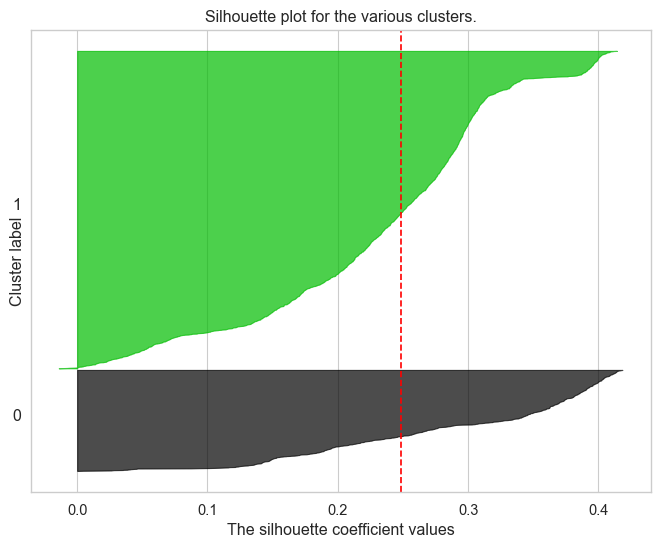

In [26]:


fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
y_lower = 10

for i in range(optimal_k):
    ith_cluster_silhouette_values = sample_silhouette_values[sk_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / optimal_k)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("Silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_yticks([])  # Clear the yaxis labels / ticks
plt.show()


## 7. Model Building: HDBSCAN

HDBSCAN performs density-based clustering, handling noise and arbitrarily shaped clusters, removing the necessity of specifying $K$. We will observe the persistence of the density tree.


In [27]:
# HDBSCAN Implementation
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10, gen_min_span_tree=True)
hdbscan_labels = clusterer.fit_predict(X)

In [28]:

num_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
num_noise = list(hdbscan_labels).count(-1)

In [ ]:
print(f"HDBSCAN Found Clusters: {num_clusters}")
print(f"HDBSCAN Noise Points: {num_noise} ({(num_noise/len(X))*100:.2f}%)")

HDBSCAN Found Clusters: 16
HDBSCAN Noise Points: 211 (7.62%)


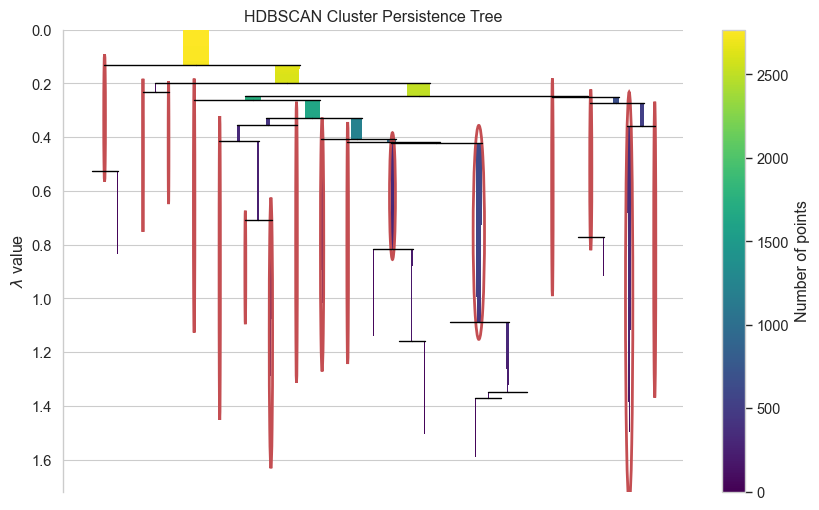

In [30]:
plt.figure(figsize=(10, 6))
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())
plt.title("HDBSCAN Cluster Persistence Tree")
plt.show()


## 8. Cluster Evaluation

Evaluate using Silhouette Score, Davies-Bouldin Index (lower is better), and Calinski-Harabasz Index (higher is better).


In [31]:
def evaluate_clusters(X, labels, name):
    # Ignore noise for silhouette if only 1 cluster + noise remains
    unique_labels = set(labels)
    if len(unique_labels) > 1 and not (len(unique_labels)==2 and -1 in unique_labels):
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        return [sil, db, ch]
    else:
        return [None, None, None]




In [32]:
metrics_custom = evaluate_clusters(X, custom_labels, "Custom K-Means")
metrics_sk = evaluate_clusters(X, sk_labels, "Sklearn K-Means")
metrics_hdbscan = evaluate_clusters(X, hdbscan_labels, "HDBSCAN")

In [33]:


eval_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Custom KMeans (K=2)': metrics_custom,
    'Sklearn KMeans (K=2)': metrics_sk,
    'HDBSCAN': metrics_hdbscan
})

display(eval_df.round(4))

,Metric,Custom KMeans (K=2),Sklearn KMeans (K=2),HDBSCAN
0,Silhouette Score,0.2486,0.2486,0.4321
1,Davies-Bouldin Index,1.7031,1.7044,2.0831
2,Calinski-Harabasz Index,493.7046,493.7068,280.3280


## 9. Visualizations

Visualizing PCA 2D projections of the clustering results for intuitive comparison.


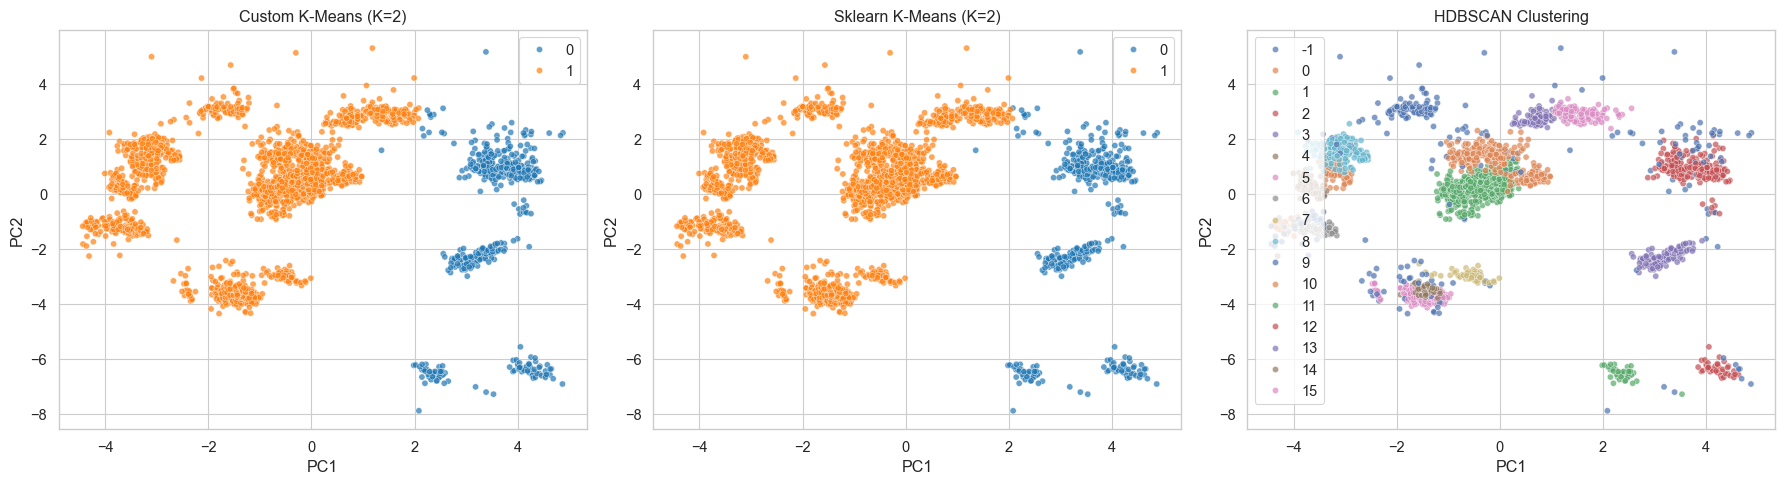

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=custom_labels, palette='tab10', alpha=0.7, s=20, ax=axes[0])
axes[0].set_title('Custom K-Means (K=2)')

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=sk_labels, palette='tab10', alpha=0.7, s=20, ax=axes[1])
axes[1].set_title('Sklearn K-Means (K=2)')

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=hdbscan_labels, palette='deep', alpha=0.7, s=20, ax=axes[2])
axes[2].set_title('HDBSCAN Clustering')

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()


## 10. Discussion & Conclusion

### Findings
- K-Means correctly identified the underlying structure of the dataset at $K=2$, which correlates heavily with the healthy vs degraded target state we observed in classification.
- The custom K-Means matched the clustering assignments of Sklearn perfectly but lacked optimizations like K-Means++ initialization.
- HDBSCAN identified varying density areas and labelled outlier cycles as noise. The comparison exposes the rigidness of distance-based clustering (K-Means) versus density-based topological clustering, where the latter is much better equipped to handle anomalies in battery cycling.

### Limitations
K-Means assumes spherical clusters. Battery cycle feature representations, even after PCA, exhibit varying variances and densities, leading to slight boundary misclassification that HDBSCAN naturally circumvents by marking edge-cases as noise.
